 1. Importation des bibliothèque exigées 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from imblearn.over_sampling import SMOTE
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import joblib

2. Importer un dataset et le convertir en DataFrame depuis un fichier Excel.

In [2]:
df = pd.read_excel("C:/Users/hajar_17vvdue/Downloads/PCOS_data_without_infertility.xlsx",sheet_name="Full_new")

# **1. Analyse Exploratoire des Données**

1. Affichage de quelques exemple de notre dataset

In [3]:
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


2. Affichage des colonnes de notre Dataset pour qu'on puisse les savoir et les analyser 

In [4]:
print(df.columns)

Index(['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)',
       'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ',
       'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)',
       'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions',
       '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)',
       'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio',
       'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)',
       'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)',
       'Unnamed: 44'],
      dtype='object')


In [5]:
df['Blood Group'].head()

0    15
1    15
2    11
3    13
4    11
Name: Blood Group, dtype: int64

A+ = 11

A- = 12

B+ = 13

B- = 14

O+ =15

O- = 16

AB+ =17

AB- = 18

3. Verification du taille de notre Dataset

In [6]:
df.shape

(541, 45)

 ### Maintenant passant au Data Cleaning 'Nettoyage de Data'

1. Savoir le type de chaque colonne , nombre des valeurs non nuls ...

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

2. Recherche s'il y'a des valeurs nul 'manquantes' dans les colonnes de notre Dataset , et  calcul de leur somme

In [8]:
df.isnull().sum()

Sl. No                      0
Patient File No.            0
PCOS (Y/N)                  0
 Age (yrs)                  0
Weight (Kg)                 0
Height(Cm)                  0
BMI                         0
Blood Group                 0
Pulse rate(bpm)             0
RR (breaths/min)            0
Hb(g/dl)                    0
Cycle(R/I)                  0
Cycle length(days)          0
Marraige Status (Yrs)       1
Pregnant(Y/N)               0
No. of aborptions           0
  I   beta-HCG(mIU/mL)      0
II    beta-HCG(mIU/mL)      0
FSH(mIU/mL)                 0
LH(mIU/mL)                  0
FSH/LH                      0
Hip(inch)                   0
Waist(inch)                 0
Waist:Hip Ratio             0
TSH (mIU/L)                 0
AMH(ng/mL)                  0
PRL(ng/mL)                  0
Vit D3 (ng/mL)              0
PRG(ng/mL)                  0
RBS(mg/dl)                  0
Weight gain(Y/N)            0
hair growth(Y/N)            0
Skin darkening (Y/N)        0
Hair loss(

On constate que la colonne unname a une 539 manquante . Donc on doit l'éliminer 

In [9]:
df.drop('Unnamed: 44',axis=1,inplace=True)

Maintenant , on soit supprimer toutes les valeurs manquantes

In [10]:
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

Pour notre analyse et implémwntation de notre modèle . On n'est besoin de convertir toutes les valeurs en valeurs numérique , et pour cela on doit convertir les colonnes . Donc , on fait cette fonction pour detecter les colonnes dont le type à convertir

In [12]:
def get_column_type(df, column_name):
    return df[column_name].dtype

for i in range(1, 44):
    column_name = df.columns[i]  
    if get_column_type(df, column_name) == 'object':  
        print(f"The column '{column_name}' has type 'object'.")


The column 'II    beta-HCG(mIU/mL)' has type 'object'.
The column 'AMH(ng/mL)' has type 'object'.


3. Convertir les données non numérique aux donnees numériques

In [13]:
df['II    beta-HCG(mIU/mL)'] = pd.to_numeric(df['II    beta-HCG(mIU/mL)'],errors='coerce')
df['AMH(ng/mL)'] = pd.to_numeric(df['AMH(ng/mL)'],errors='coerce')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

In [15]:
df.shape

(541, 44)

### Etude de Corrélation et Les Dépendeces entre les colonnes

In [16]:
df.corr()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
Sl. No,1.000000,1.000000,0.060998,0.067133,-0.082823,-0.011700,-0.083578,0.001705,-0.044533,-0.015196,...,0.160834,0.154135,0.000110,0.013399,0.009798,0.049658,0.086969,0.289706,0.244608,0.027219
Patient File No.,1.000000,1.000000,0.060998,0.067133,-0.082823,-0.011700,-0.083578,0.001705,-0.044533,-0.015196,...,0.160834,0.154135,0.000110,0.013399,0.009798,0.049658,0.086969,0.289706,0.244608,0.027219
PCOS (Y/N),0.060998,0.060998,1.000000,-0.168513,0.211938,0.068254,0.199534,0.036433,0.091821,0.036928,...,0.286077,0.377933,0.065337,0.007942,0.038032,0.603346,0.648327,0.132992,0.097690,0.106648
Age (yrs),0.067133,0.067133,-0.168513,1.000000,-0.029734,-0.119819,0.021261,-0.010954,0.045831,0.087382,...,-0.032921,-0.037694,-0.025911,0.073587,0.066788,-0.110793,-0.159395,-0.016352,-0.079250,-0.104238
Weight (Kg),-0.082823,-0.082823,0.211938,-0.029734,1.000000,0.420098,0.901675,0.072682,0.019983,0.043614,...,0.063983,0.162015,-0.068236,0.027608,0.131402,0.173751,0.124290,-0.021368,-0.073207,-0.010100
Height(Cm),-0.011700,-0.011700,0.068254,-0.119819,0.420098,1.000000,-0.006878,0.040825,-0.074339,-0.029459,...,0.061129,0.032418,0.012943,-0.067959,0.011116,0.106189,0.075358,-0.026705,0.059426,-0.054035
BMI,-0.083578,-0.083578,0.199534,0.021261,0.901675,-0.006878,1.000000,0.061939,0.050529,0.061905,...,0.045656,0.159279,-0.080192,0.069491,0.139975,0.142886,0.104204,-0.011610,-0.111522,0.009349
Blood Group,0.001705,0.001705,0.036433,-0.010954,0.072682,0.040825,0.061939,1.000000,0.047572,-0.023766,...,0.039029,-0.035090,0.064035,0.030898,0.054014,0.061332,0.013974,-0.035667,-0.015725,-0.015335
Pulse rate(bpm),-0.044533,-0.044533,0.091821,0.045831,0.019983,-0.074339,0.050529,0.047572,1.000000,0.303804,...,-0.003039,0.059804,-0.038881,-0.025510,0.007623,0.040390,0.049182,-0.048356,-0.034202,-0.041241
RR (breaths/min),-0.015196,-0.015196,0.036928,0.087382,0.043614,-0.029459,0.061905,-0.023766,0.303804,1.000000,...,0.029242,0.135479,-0.047451,0.017323,0.052631,0.069731,0.012441,-0.031051,-0.021893,-0.063930


On constate que le diagonale de ce tableau qui est logique . Car c'est la correlation de chaque critere avec lui meme .

Notre visee de cette analyse c'est la detection du SOPK , donc notre variable cible est 'PCOS (Y/N)'

In [17]:
correlation_avec_variablecible =  df.corr()['PCOS (Y/N)'].abs().sort_values(ascending=False)
print(correlation_avec_variablecible)

PCOS (Y/N)                1.000000
Follicle No. (R)          0.648327
Follicle No. (L)          0.603346
Skin darkening (Y/N)      0.475733
hair growth(Y/N)          0.464667
Weight gain(Y/N)          0.441047
Cycle(R/I)                0.401644
Fast food (Y/N)           0.377933
Pimples(Y/N)              0.286077
AMH(ng/mL)                0.263863
Weight (Kg)               0.211938
BMI                       0.199534
Cycle length(days)        0.178480
Hair loss(Y/N)            0.172879
 Age (yrs)                0.168513
Waist(inch)               0.164598
Hip(inch)                 0.162297
Avg. F size (L) (mm)      0.132992
Marraige Status (Yrs)     0.112897
Endometrium (mm)          0.106648
Avg. F size (R) (mm)      0.097690
Pulse rate(bpm)           0.091821
Hb(g/dl)                  0.087170
Vit D3 (ng/mL)            0.085494
Height(Cm)                0.068254
Reg.Exercise(Y/N)         0.065337
LH(mIU/mL)                0.063879
Sl. No                    0.060998
Patient File No.    

On a fait la corrélance du variable cible avec toutes les colonnes , On fait la valeur absolue car on est interessé à mieux corrélants soit positif ou négatif . Donc on va interpreter les correlations qui sont plus grand que 0.1

Maintenant , on va changer le nom d'une colonne dont il y'a une faute photograpghe

In [18]:
df.rename(columns={'Marraige Status (Yrs)': 'Marriage Status (Yrs)'}, inplace=True)

## Analyse dea relations de correlations en utilisant les graphes

1. Illustrant la relation entre l'existance du SOPK avec l'age

In [19]:
df[' Age (yrs)'].head()

0    28
1    36
2    33
3    37
4    25
Name:  Age (yrs), dtype: int64

Pour mieux analyser cette relation , il est preferable de regrouper les ages en categorie :

In [20]:
groupe_age = [0,18,25,35,45,float('inf')]
groupe_labels = ['<18','18-25','26-35','36-45','45+']
df['Age Group'] = pd.cut(df[' Age (yrs)'],bins = groupe_age,labels = groupe_labels)

Dans l'etape prochaine , on va groupe les deux colonnes SOPK et l age , apres on veut calculer le nombre d'occurance dans chaque groupe d'age . Finalement , on va utiliser la fonction unstack et cela pour categoriser les deux cas du SOPK si il est affecte ou non.

In [21]:
age_group_counts = df.groupby(['Age Group', 'PCOS (Y/N)']).size().unstack()
type(age_group_counts)

C:\Users\hajar_17vvdue\AppData\Local\Temp\ipykernel_23764\3400726143.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_counts = df.groupby(['Age Group', 'PCOS (Y/N)']).size().unstack()


pandas.core.frame.DataFrame

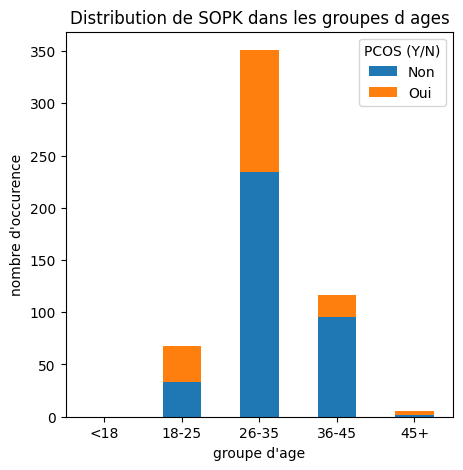

In [94]:
age_group_counts.plot(kind='bar', stacked=True, figsize=(5, 5))
plt.title('Distribution de SOPK dans les groupes d ages')
plt.xlabel("groupe d'age")
plt.ylabel("nombre d'occurence")
plt.legend(title='PCOS (Y/N)', loc='upper right', labels=['Non', 'Oui'])
plt.xticks(rotation=0)
plt.show()

### En se basant sur notre graphe , on peut conclure que le SOPK atteint plus les femmes entre 26-35 puis 18-25 . et les femmes de 45 ou plus sont les moins atteints

Maintenant , on va analyser les donnees numeriques qui ne sont pas booleans dans le cas ou les femmes sont atteints de SOPK

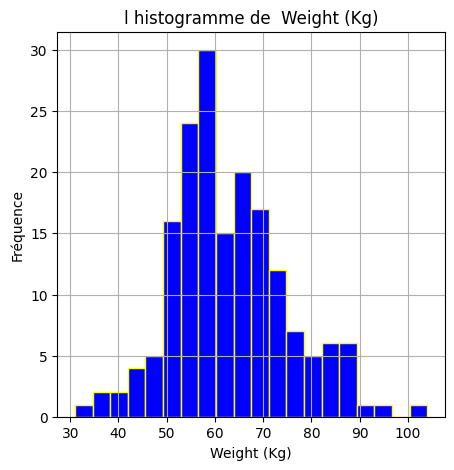

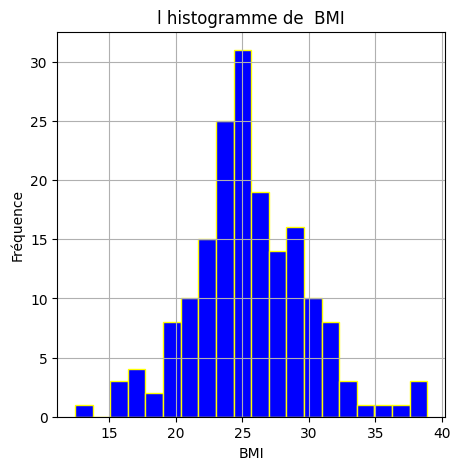

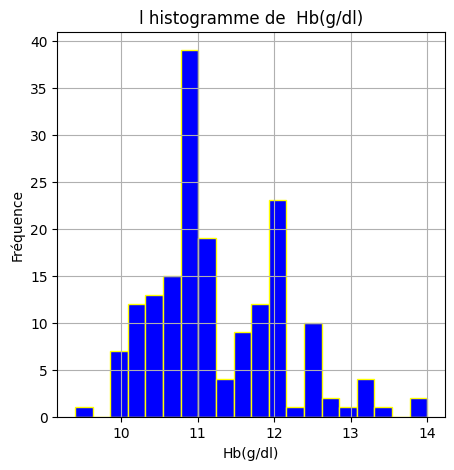

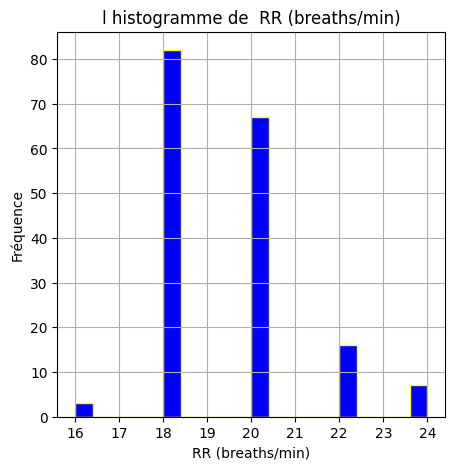

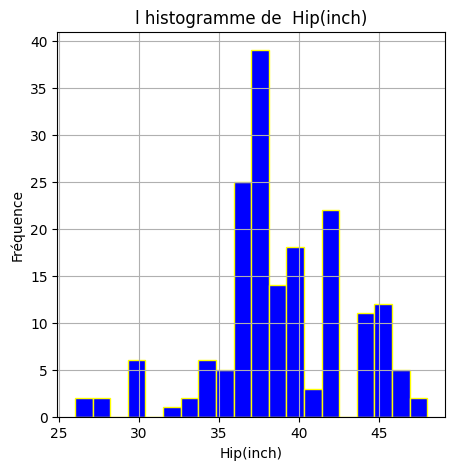

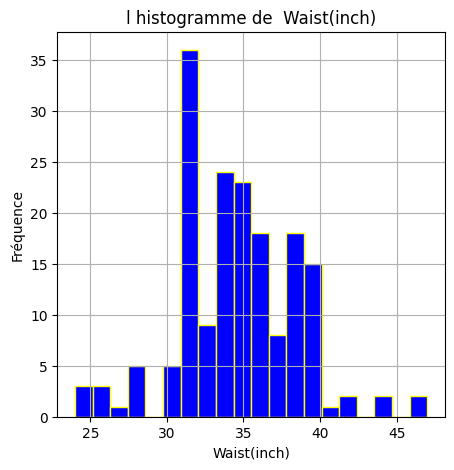

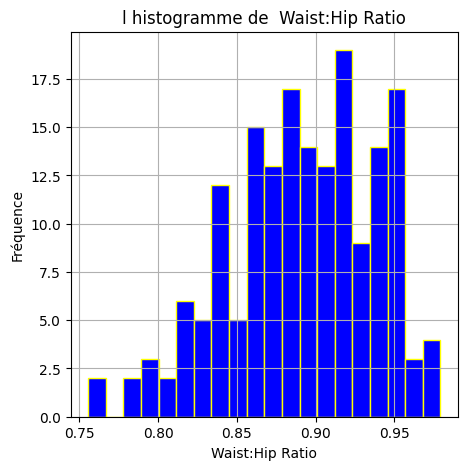

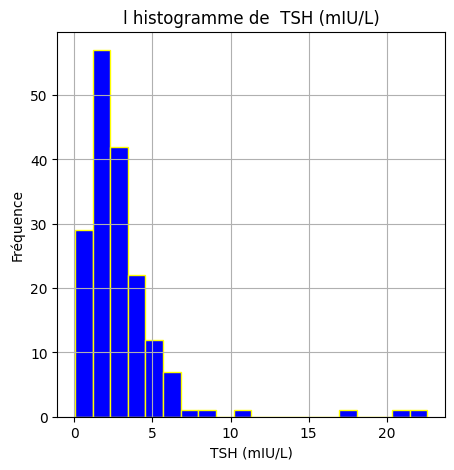

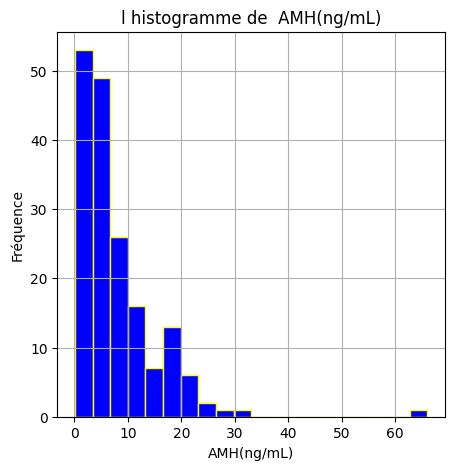

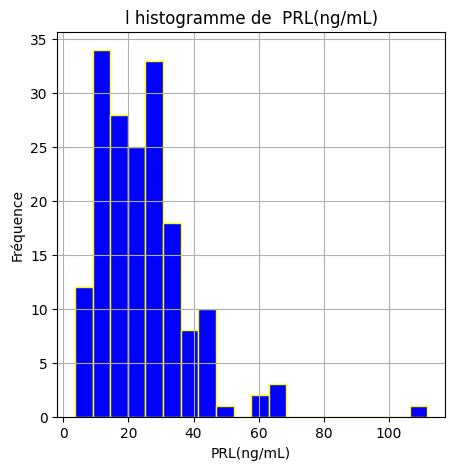

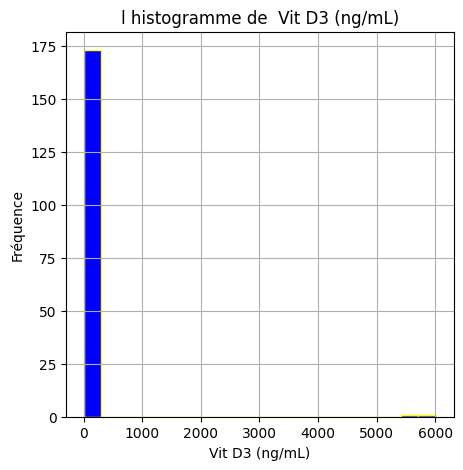

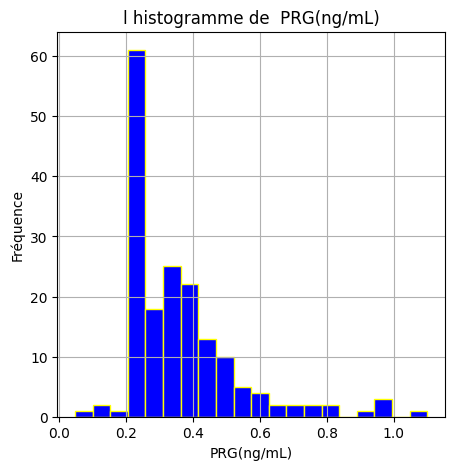

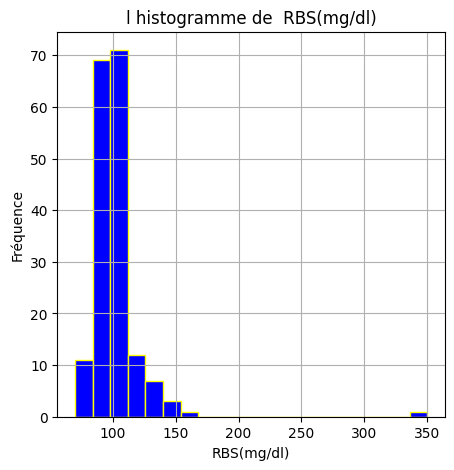

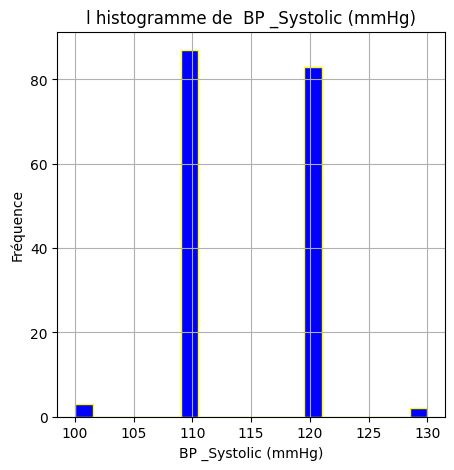

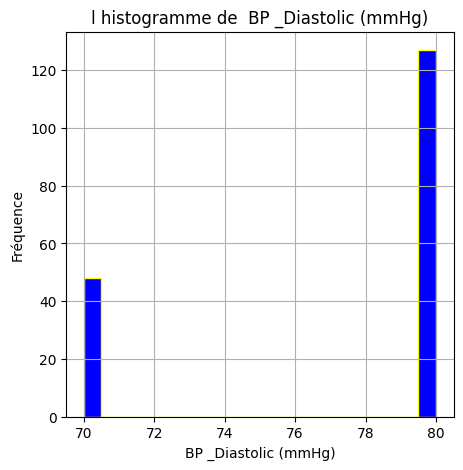

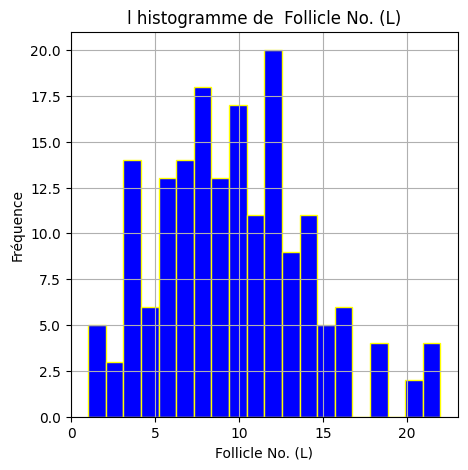

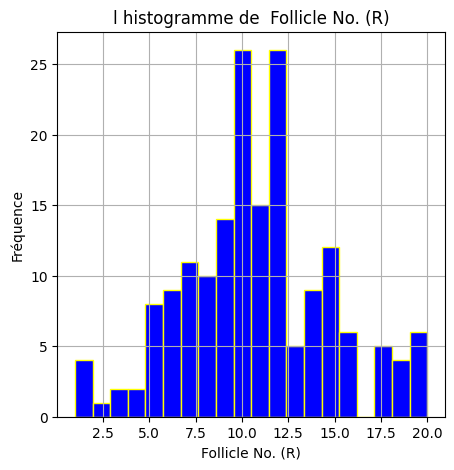

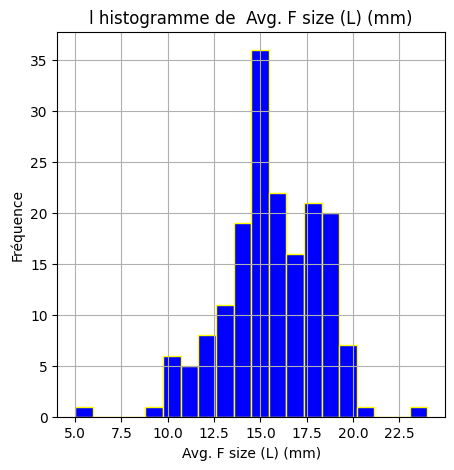

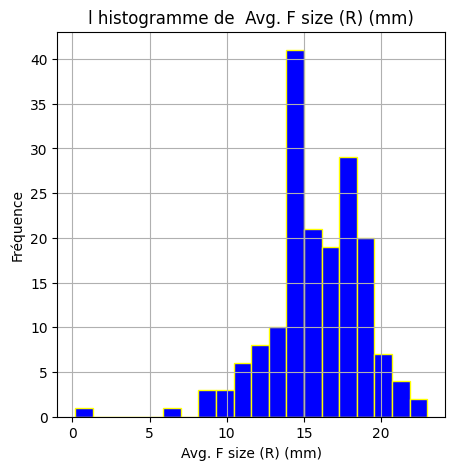

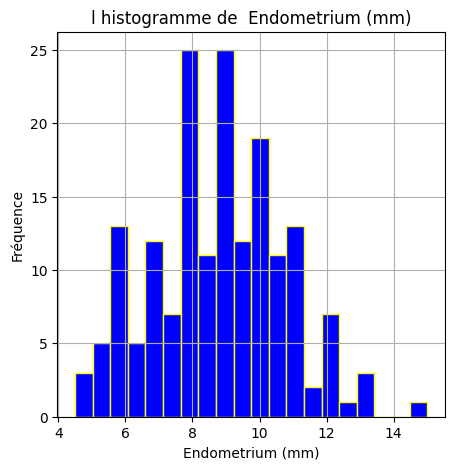

In [97]:
attributs_numerique = ['Weight (Kg)', 'BMI', 'Hb(g/dl)','RR (breaths/min)',
                        'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)',
                        'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)',
                        'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)',
                        'Endometrium (mm)']
df_pcos = df[df['PCOS (Y/N)']==1]

for attribut in attributs_numerique:
    plt.figure(figsize=(5,5))
    plt.hist(df_pcos[attribut], bins=20, color='blue', edgecolor='yellow')
    plt.title(f'l histogramme de  {attribut}')
    plt.xlabel(attribut)
    plt.ylabel('Fréquence')
    plt.grid(True)
    plt.show()

## Résultats:

- BMI == 25 dont le frequence est maximale signifie qu'il y a une relation entre l'obesite et SOPK.
- 10< Hemoglobine < 11  faible par rapport au normale signifie que la plupart des femmes qui ont SOPK souffre d'une anémie qui cause la fatigue ... .
- WHR : rapport taille-hanches > 0.95  plus grand de normal , et peut causer la diabete a cause de graisse abdominale .
- AMH : Hormone Anti-Müllérienne dans cas normal se varie entre 1 MH > 4 .
- Prolactine : l'hormone de lait chez la femme , dans le cas normal entre 4.8 & 23.3 .
- RBS :glycémie aléatoire , le normal est entre 70 & 140 .
- endomètre == 8 ,  considéré comme normal pendant la phase lutéale.
- PB diastolic => 80 est considéré comme eleve .


## sélection de caractéristiques

Maintenant , on va selecter les top 10 caracteristiques qui sont les plus correlants . Et cela en se basant sur correlation_avec_variablecible dont on a deja stocke les correlations de SOPK yes / non avec toutes les colonnes .

In [24]:
top_10_caracteristiques = correlation_avec_variablecible[0:11]
print(top_10_caracteristiques)

PCOS (Y/N)              1.000000
Follicle No. (R)        0.648327
Follicle No. (L)        0.603346
Skin darkening (Y/N)    0.475733
hair growth(Y/N)        0.464667
Weight gain(Y/N)        0.441047
Cycle(R/I)              0.401644
Fast food (Y/N)         0.377933
Pimples(Y/N)            0.286077
AMH(ng/mL)              0.263863
Weight (Kg)             0.211938
Name: PCOS (Y/N), dtype: float64


In [25]:
df_new = df


In [26]:
df_new.isnull().sum()

Sl. No                    0
Patient File No.          0
PCOS (Y/N)                0
 Age (yrs)                0
Weight (Kg)               0
Height(Cm)                0
BMI                       0
Blood Group               0
Pulse rate(bpm)           0
RR (breaths/min)          0
Hb(g/dl)                  0
Cycle(R/I)                0
Cycle length(days)        0
Marriage Status (Yrs)     1
Pregnant(Y/N)             0
No. of aborptions         0
  I   beta-HCG(mIU/mL)    0
II    beta-HCG(mIU/mL)    1
FSH(mIU/mL)               0
LH(mIU/mL)                0
FSH/LH                    0
Hip(inch)                 0
Waist(inch)               0
Waist:Hip Ratio           0
TSH (mIU/L)               0
AMH(ng/mL)                1
PRL(ng/mL)                0
Vit D3 (ng/mL)            0
PRG(ng/mL)                0
RBS(mg/dl)                0
Weight gain(Y/N)          0
hair growth(Y/N)          0
Skin darkening (Y/N)      0
Hair loss(Y/N)            0
Pimples(Y/N)              0
Fast food (Y/N)     

In [27]:
df_new.dropna(inplace=True)

les couleurs les plus claires désigne les corrélations les plus élévées , dans le diagonale on a une corrélation plus claire avec 1 comme valeur qui est normale , car il désigne la corrélation entre le variable et lui meme .

In [28]:
df_new['PCOS (Y/N)'].value_counts()

PCOS (Y/N)
0    362
1    175
Name: count, dtype: int64

In [29]:
df_new.columns

Index(['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)',
       'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ',
       'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)',
       'Marriage Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions',
       '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)',
       'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio',
       'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)',
       'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)',
       'Age Group'],
      dtype='object')

In [30]:
df_new.drop(['Age Group'], axis=1, inplace=True)


# La détection du SOPK avec l'utilisation de la régression Logistique


### séparation des caractéristiques et de la cible
on a x : Elles designet les caractéristiques .
et   y : designe la variable cible qui est un varibale dont la valeur est soit 0 ou 1 qui designe soit affecté ou non.

In [31]:
x = df_new.drop(['PCOS (Y/N)'],axis=1)
y = df_new['PCOS (Y/N)']

### La division des données en bases de test et entrainement
On va divisé notre base en quatre base , deux pour le test et deux pour l'entrainement en utilisant  la fonction train_test_split


In [32]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [33]:
x_train.head()

,Sl. No,Patient File No.,Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
510,511,511,24,57.0,158.496,22.700000,17,70,20,11.2,...,0,0.0,0,120,70,8,10,18.0,19.0,8.4
194,195,195,29,50.0,152.000,21.641274,13,74,18,10.8,...,1,1.0,0,120,80,5,6,13.0,12.0,7.0
351,352,352,36,54.0,148.000,24.700000,13,78,24,10.2,...,1,1.0,0,100,80,10,7,13.0,15.0,9.0
182,183,183,42,50.0,152.000,21.641274,11,73,18,10.8,...,1,0.0,0,110,80,1,1,11.0,12.0,5.5
303,304,304,25,57.0,148.000,26.022644,15,72,20,10.0,...,1,0.0,0,110,80,10,12,15.0,14.0,9.0


### Création une instance du modèle logisticRegression

In [34]:
regression_logistique = LogisticRegression()

### L'entraînement du modele en ajustant notre modele a nos donnees

In [35]:
regression_logistique.fit(x_train,y_train)

C:\Users\hajar_17vvdue\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

### Effectuer des predictions sur les donnees du test x_test
y_pred_regression : Contient les prédictions de classe (0, 1, etc.) pour les observations de x_test.

In [36]:
y_pred_regression = regression_logistique.predict(x_test)


### Métrics d'évaluation

Précision (Accuracy) :  La précision mesure la proportion de prédictions correctes sur l'ensemble des prédictions.

Matrice de confusion :  C'est un tableau qui montre le nombre de vraies prédictions et d'erreurs par classe.
 
Rapport de classification : Fournit un résumé des performances pour chaque classe en termes de précision, rappel et F1-score.


In [37]:
accuracy_reg = accuracy_score(y_test,y_pred_regression)
conf_matrix_reg = confusion_matrix(y_test,y_pred_regression)
rapport_classification_reg= classification_report(y_test, y_pred_regression)
mse_logistic_regression = mean_squared_error(y_test, y_pred_regression)

In [38]:
print("Accuracy:", accuracy_reg)
print("La matrice de confusion:")
print(conf_matrix_reg)
print("Rapport de classification:")
print(rapport_classification_reg)
print('Erreur quadratique moyenne du meilleur modèle')
print(mse_logistic_regression)

Accuracy: 0.8333333333333334
La matrice de confusion:
[[64 10]
 [ 8 26]]
Rapport de classification:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        74
           1       0.72      0.76      0.74        34

    accuracy                           0.83       108
   macro avg       0.81      0.81      0.81       108
weighted avg       0.84      0.83      0.83       108

Erreur quadratique moyenne du meilleur modèle
0.16666666666666666


# Detection du SOPK avec arbre de décision

### Création une instance du modèle arbre de decision

In [39]:


tree_model = tree.DecisionTreeClassifier(max_depth=2)


### L'entraînement du modele en ajustant notre modele a nos donnees

In [40]:
tree_model = tree_model.fit(x_train, y_train)

### Effectuer des predictions sur les donnees du test x_test
y_pred_regression : Contient les prédictions de classe (0, 1, etc.) pour les observations de x_test.

In [41]:
y_pred_tree = tree_model.predict(x_test)

In [42]:
accuracy_tree = accuracy_score(y_test,y_pred_tree)
conf_matrix_tree = confusion_matrix(y_test,y_pred_tree)
rapport_classification_tree = classification_report(y_test, y_pred_tree)

In [43]:
print("Accuracy de l arbre de decision:", accuracy_tree)
print("La matrice de confusion de l arbre de decision:")
print(conf_matrix_tree)
print("Rapport de classification de l arbre de decision:")
print(rapport_classification_tree)

Accuracy de l arbre de decision: 0.8240740740740741
La matrice de confusion de l arbre de decision:
[[68  6]
 [13 21]]
Rapport de classification de l arbre de decision:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88        74
           1       0.78      0.62      0.69        34

    accuracy                           0.82       108
   macro avg       0.81      0.77      0.78       108
weighted avg       0.82      0.82      0.82       108



On va utiliser GridSearchCv pour trouver les  meilleurs parametres a utiliser comme max_depth qui designe la taille d'un arbre

In [44]:
param_grid = {
    'max_depth': [2, 4, 6, 8, 10, 12 ,14] 
}

model= DecisionTreeClassifier()
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    verbose=2
)
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV] END ........................................max_depth=2; total time=   0.0s
[CV] END ........................................max_depth=2; total time=   0.0s
[CV] END ........................................max_depth=2; total time=   0.0s
[CV] END ........................................max_depth=2; total time=   0.0s
[CV] END ........................................max_depth=2; total time=   0.0s
[CV] END ........................................max_depth=4; total time=   0.0s
[CV] END ........................................max_depth=4; total time=   0.0s
[CV] END ........................................max_depth=4; total time=   0.0s
[CV] END ........................................max_depth=4; total time=   0.0s
[CV] END ........................................max_depth=4; total time=   0.0s
[CV] END ........................................max_depth=6; total time=   0.0s
[CV] END ........................................

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [2, 4, 6, 8, 10, 12, 14]}, verbose=2)

In [45]:
best_max_depth = grid_search.best_params_['max_depth']
print(f"Best max_depth: {best_max_depth}")

best_tree_model = grid_search.best_estimator_
y_pred_tree1 = best_tree_model.predict(x_test)

Best max_depth: 2


On trouve 2 , Donc c'est le meme valeur qu'on a pris des debut .

On constate que l'accuracy de la regression logistique est plus grand que celle de l'arbre de decisoon aussi que les autres parametres .

Donc , on va eliminer l'arbre de decision eet passer a tester les autres modeles (algorithmes).

#  La detection du SOPK avec SVM

### Création une instance du modèle arbre de decision

In [46]:
svm_class = SVC(kernel='linear')



### L'entraînement du modele en ajustant notre modele a nos donnees

In [47]:
svm_class.fit(x_train, y_train)

SVC(kernel='linear')

### Effectuer des predictions sur les donnees du test x_test
y_pred_regression : Contient les prédictions de classe (0, 1, etc.) pour les observations de x_test.

In [48]:
y_pred_svm = svm_class.predict(x_test)

In [49]:
accuracy_svm = accuracy_score(y_test,y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test,y_pred_svm)
rapport_classification_svm = classification_report(y_test, y_pred_svm)

In [50]:
print("Accuracy de svm:", accuracy_svm)
print("La matrice de confusion du svm:")
print(conf_matrix_svm)
print("Rapport de classification du svm:")
print(rapport_classification_svm)

Accuracy de svm: 0.8611111111111112
La matrice de confusion du svm:
[[67  7]
 [ 8 26]]
Rapport de classification du svm:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        74
           1       0.79      0.76      0.78        34

    accuracy                           0.86       108
   macro avg       0.84      0.84      0.84       108
weighted avg       0.86      0.86      0.86       108



 On l'accuracy de la regression logistique est : 0.8333333333333334 et celle de SVM est  0.8611111111111112 . Mais le SVM est plus long et plus complexe . Donc , on doit continuer avec la regression logistiqe et la comparer avec les autres algorithmes

# La detection du SOPK avec les Forêts aléatoires

### Création une instance du modèle arbre de decision

In [51]:
random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(x_train, y_train)

RandomForestClassifier()

### Effectuer des predictions sur les donnees du test x_test
y_pred_regression : Contient les prédictions de classe (0, 1, etc.) pour les observations de x_test.

In [52]:
y_pred_random_forest = random_forest.predict(x_test)

In [53]:
accuracy_forest= accuracy_score(y_test,y_pred_random_forest)
conf_matrix_forest = confusion_matrix(y_test,y_pred_random_forest)
rapport_classification_forest = classification_report(y_test, y_pred_random_forest)

In [54]:
print("Accuracy de random forest:", accuracy_forest)
print("La matrice de confusion du random forest:")
print(conf_matrix_forest)
print("Rapport de classification du random forest:")
print(rapport_classification_svm)

Accuracy de random forest: 0.8888888888888888
La matrice de confusion du random forest:
[[71  3]
 [ 9 25]]
Rapport de classification du random forest:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        74
           1       0.79      0.76      0.78        34

    accuracy                           0.86       108
   macro avg       0.84      0.84      0.84       108
weighted avg       0.86      0.86      0.86       108



# La detection du SOPK avec KNN

### Création une instance du modèle arbre de decision

In [55]:

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train)


KNeighborsClassifier()

In [56]:
y_pred_knn = knn_model.predict(x_test)

C:\Users\hajar_17vvdue\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\hajar_17vvdue\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^

In [57]:
accuracy_knn = accuracy_score(y_test,y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test,y_pred_knn)
rapport_classification_knn = classification_report(y_test, y_pred_knn)

In [58]:
print("Accuracy de knn", accuracy_knn)
print("La matrice de confusion du knn :")
print(conf_matrix_knn)
print("Rapport de classification du knn:")
print(rapport_classification_knn)

Accuracy de knn 0.7129629629629629
La matrice de confusion du knn :
[[67  7]
 [24 10]]
Rapport de classification du knn:
              precision    recall  f1-score   support

           0       0.74      0.91      0.81        74
           1       0.59      0.29      0.39        34

    accuracy                           0.71       108
   macro avg       0.66      0.60      0.60       108
weighted avg       0.69      0.71      0.68       108



# La detection du SOPK avec Naive de Bayes

In [59]:
naive_bayes = GaussianNB()
naive_bayes.fit(x_train, y_train)


GaussianNB()

In [60]:
y_pred_bayes = naive_bayes.predict(x_test)

In [61]:
accuracy_bayes = accuracy_score(y_test,y_pred_bayes)
conf_matrix_bayes = confusion_matrix(y_test,y_pred_bayes)
rapport_classification_bayes = classification_report(y_test, y_pred_bayes)

In [62]:
print("Accuracy de bayes", accuracy_bayes)
print("La matrice de confusion de bayes:")
print(conf_matrix_bayes)
print("Rapport de classification du bayes:")
print(rapport_classification_bayes)

Accuracy de bayes 0.8055555555555556
La matrice de confusion de bayes:
[[55 19]
 [ 2 32]]
Rapport de classification du bayes:
              precision    recall  f1-score   support

           0       0.96      0.74      0.84        74
           1       0.63      0.94      0.75        34

    accuracy                           0.81       108
   macro avg       0.80      0.84      0.80       108
weighted avg       0.86      0.81      0.81       108



In [63]:
df.columns

Index(['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)',
       'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ',
       'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)',
       'Marriage Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions',
       '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)',
       'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio',
       'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)',
       'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)'],
      dtype='object')

In [64]:
correlation_avec_variablecible =  df.corr()['PCOS (Y/N)'].abs().sort_values(ascending=False)
print(correlation_avec_variablecible)

PCOS (Y/N)                1.000000
Follicle No. (R)          0.649591
Follicle No. (L)          0.600376
Skin darkening (Y/N)      0.479234
hair growth(Y/N)          0.464201
Weight gain(Y/N)          0.441193
Cycle(R/I)                0.404407
Fast food (Y/N)           0.379460
Pimples(Y/N)              0.293782
AMH(ng/mL)                0.259442
Weight (Kg)               0.215770
BMI                       0.203884
Cycle length(days)        0.184275
Hair loss(Y/N)            0.174093
 Age (yrs)                0.167892
Waist(inch)               0.159339
Hip(inch)                 0.156394
Avg. F size (L) (mm)      0.128089
Marriage Status (Yrs)     0.110604
Endometrium (mm)          0.103203
Avg. F size (R) (mm)      0.093478
Pulse rate(bpm)           0.092428
Hb(g/dl)                  0.089103
Vit D3 (ng/mL)            0.086195
Height(Cm)                0.068536
Reg.Exercise(Y/N)         0.067619
LH(mIU/mL)                0.064239
Sl. No                    0.060096
Patient File No.    

In [65]:

columns_to_copy = [
    'PCOS (Y/N)',
    'Skin darkening (Y/N)', 
    'hair growth(Y/N)', 
    'Weight gain(Y/N)', 
    'Cycle(R/I)', 
    'Fast food (Y/N)', 
    'Pimples(Y/N)', 
    'Hair loss(Y/N)',  
    'Weight (Kg)', 
    'Waist(inch)', 
    'Hip(inch)', 
    'Reg.Exercise(Y/N)', 
    'Pregnant(Y/N)',
    'Cycle length(days)'
]

data_patient = df_new[columns_to_copy].copy()


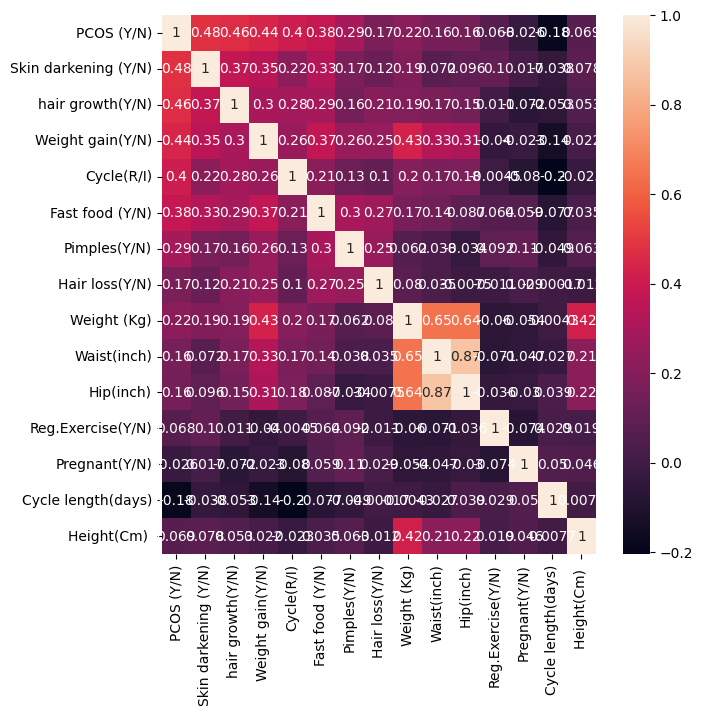

In [100]:
plt.figure(figsize=(7,7))
sns.heatmap(data_patient.corr(),annot=True)
plt.show()

In [66]:
data_patient['Height(Cm) '] = df_new['Height(Cm) ']

In [67]:
data_patient.head(5)

,PCOS (Y/N),Skin darkening (Y/N),hair growth(Y/N),Weight gain(Y/N),Cycle(R/I),Fast food (Y/N),Pimples(Y/N),Hair loss(Y/N),Weight (Kg),Waist(inch),Hip(inch),Reg.Exercise(Y/N),Pregnant(Y/N),Cycle length(days),Height(Cm)
0,0,0,0,0,2,1.0,0,0,44.6,30,36,0,0,5,152.0
1,0,0,0,0,2,0.0,0,0,65.0,32,38,0,1,5,161.5
2,1,0,0,0,2,1.0,1,1,68.8,36,40,0,1,5,165.0
3,0,0,0,0,2,0.0,0,0,65.0,36,42,0,0,5,148.0
4,0,0,0,0,2,0.0,0,1,52.0,30,37,0,1,5,161.0


## La regression logistique pour detection du sopk chez un patient


In [68]:
x_pat = data_patient.drop(['PCOS (Y/N)'],axis=1)
y_pat = data_patient['PCOS (Y/N)']

In [69]:
x_train1,x_test1,y_train1,y_test1 = train_test_split(x_pat,y_pat,test_size=0.2,random_state=42)

In [113]:
regression_logistique_pa = LogisticRegression(solver='liblinear', max_iter=1000)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}
grid_search = GridSearchCV(regression_logistique_pa, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train1, y_train1)


print("les meilleurs parametres:", grid_search.best_params_)
regression_logistique_pa1= LogisticRegression(C=1, penalty='l1', solver='liblinear')

Best Parameters: {'C': 1, 'penalty': 'l1'}


In [114]:
regression_logistique_pa1.fit(x_train1,y_train1)

LogisticRegression(C=1, penalty='l1', solver='liblinear')

In [116]:
y_pred_regression1 = regression_logistique_pa1.predict(x_test1)

In [117]:
accuracy_pa = accuracy_score(y_test1,y_pred_regression1)
conf_matrix_pa = confusion_matrix(y_test1,y_pred_regression1)
rapport_classification_pa= classification_report(y_test1, y_pred_regression1)


In [118]:
print("Accuracy:", accuracy_pa)
print("La matrice de confusion:")
print(conf_matrix_pa)
print("Rapport de classification:")
print(rapport_classification_pa)


Accuracy: 0.8425925925925926
La matrice de confusion:
[[70  4]
 [13 21]]
Rapport de classification:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89        74
           1       0.84      0.62      0.71        34

    accuracy                           0.84       108
   macro avg       0.84      0.78      0.80       108
weighted avg       0.84      0.84      0.84       108



## Detection du SOPK avec Svm pour Patient

In [119]:
svm_class = SVC(kernel='linear')
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}
grid_search = GridSearchCV(svm_class, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train1, y_train1)
print("meilleurs parametre:", grid_search.best_params_)

meilleurs parametre: {'C': 0.1, 'gamma': 1, 'kernel': 'linear'}


In [122]:
svm_class = SVC(C= 0.1, gamma=1, kernel='linear')

In [123]:
svm_class.fit(x_train1, y_train1)

SVC(C=0.1, gamma=1, kernel='linear')

In [124]:
y_pred_svm_pa = svm_class.predict(x_test1)

In [125]:
accuracy_svm = accuracy_score(y_test1,y_pred_svm_pa)
conf_matrix_svm = confusion_matrix(y_test1,y_pred_svm_pa)
rapport_classification_svm = classification_report(y_test1, y_pred_svm_pa)

In [126]:
print("Accuracy de svm:", accuracy_svm)
print("La matrice de confusion du svm:")
print(conf_matrix_svm)
print("Rapport de classification du svm:")
print(rapport_classification_svm)

Accuracy de svm: 0.8518518518518519
La matrice de confusion du svm:
[[70  4]
 [12 22]]
Rapport de classification du svm:
              precision    recall  f1-score   support

           0       0.85      0.95      0.90        74
           1       0.85      0.65      0.73        34

    accuracy                           0.85       108
   macro avg       0.85      0.80      0.82       108
weighted avg       0.85      0.85      0.85       108



## La detection du SOPK avec Naive de Bayes pour un patient

In [133]:

param_grid = {
    'var_smoothing': [1e-12, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
}
grid_search = GridSearchCV(naive_bayes, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train1, y_train1)
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'var_smoothing': 1e-12}


In [134]:
naive_bayes = GaussianNB(var_smoothing = 1e-12)

In [135]:
naive_bayes.fit(x_train1, y_train1)

GaussianNB(var_smoothing=1e-12)

In [136]:
data_patient.columns

Index(['PCOS (Y/N)', 'Skin darkening (Y/N)', 'hair growth(Y/N)',
       'Weight gain(Y/N)', 'Cycle(R/I)', 'Fast food (Y/N)', 'Pimples(Y/N)',
       'Hair loss(Y/N)', 'Weight (Kg)', 'Waist(inch)', 'Hip(inch)',
       'Reg.Exercise(Y/N)', 'Pregnant(Y/N)', 'Cycle length(days)',
       'Height(Cm) '],
      dtype='object')

In [137]:
y_pred_bayes_pa = naive_bayes.predict(x_test1)

In [138]:
accuracy_bayes = accuracy_score(y_test1,y_pred_bayes_pa)
conf_matrix_bayes = confusion_matrix(y_test1,y_pred_bayes_pa)
rapport_classification_bayes = classification_report(y_test1, y_pred_bayes_pa)

In [139]:
print("Accuracy de bayes", accuracy_bayes)
print("La matrice de confusion de bayes:")
print(conf_matrix_bayes)
print("Rapport de classification du bayes:")
print(rapport_classification_bayes)

Accuracy de bayes 0.8333333333333334
La matrice de confusion de bayes:
[[66  8]
 [10 24]]
Rapport de classification du bayes:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88        74
           1       0.75      0.71      0.73        34

    accuracy                           0.83       108
   macro avg       0.81      0.80      0.80       108
weighted avg       0.83      0.83      0.83       108



## La detection du SOPK avec les Forêts aléatoires pour un patient

In [140]:
random_forest_pa = RandomForestClassifier(n_estimators=100)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
grid_search = GridSearchCV(
    random_forest, 
    param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=2
)
grid_search.fit(x_train1, y_train1)
print("meilleurs parametres:", grid_search.best_params_)
random_forest_pa.fit(x_train1, y_train1)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


C:\Users\hajar_17vvdue\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}


RandomForestClassifier()

In [143]:
random_forest_pa = RandomForestClassifier(max_depth= 20, max_features='log2', min_samples_leaf= 4, min_samples_split= 10, n_estimators=50)

In [145]:
random_forest_pa.fit(x_train1,y_train1)

RandomForestClassifier(max_depth=20, max_features='log2', min_samples_leaf=4,
                       min_samples_split=10, n_estimators=50)

In [146]:
y_pred_random_forest_pa = random_forest_pa.predict(x_test1)

In [147]:
accuracy_forest= accuracy_score(y_test1,y_pred_random_forest_pa)
conf_matrix_forest = confusion_matrix(y_test1,y_pred_random_forest_pa)
rapport_classification_forest = classification_report(y_test1, y_pred_random_forest_pa)

In [148]:
print("Accuracy de random forest:", accuracy_forest)
print("La matrice de confusion du random forest:")
print(conf_matrix_forest)
print("Rapport de classification du random forest:")
print(rapport_classification_svm)

Accuracy de random forest: 0.8148148148148148
La matrice de confusion du random forest:
[[69  5]
 [15 19]]
Rapport de classification du random forest:
              precision    recall  f1-score   support

           0       0.85      0.95      0.90        74
           1       0.85      0.65      0.73        34

    accuracy                           0.85       108
   macro avg       0.85      0.80      0.82       108
weighted avg       0.85      0.85      0.85       108



## Detection du SOPK avec arbre de décision pour un patient

In [167]:

tree_model_pa = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(tree_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(x_train1, y_train1)
print("meilleurs parametres:", grid_search.best_params_)
best_tree_model = grid_search.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits
meilleurs parametres: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [162]:
tree_model_pa = DecisionTreeClassifier(criterion = 'gini', max_depth= None, min_samples_leaf= 4,min_samples_split= 10)

In [163]:
tree_model_pa.fit(x_train1,y_train1)

DecisionTreeClassifier(min_samples_leaf=4, min_samples_split=10)

In [164]:
y_pred_tree_pa = tree_model_pa.predict(x_test1)

In [165]:
accuracy_tree = accuracy_score(y_test1,y_pred_tree)
conf_matrix_tree = confusion_matrix(y_test1,y_pred_tree)
rapport_classification_tree = classification_report(y_test1, y_pred_tree)

In [157]:
print("Accuracy de l arbre de decision:", accuracy_tree)
print("La matrice de confusion de l arbre de decision:")
print(conf_matrix_tree)
print("Rapport de classification de l arbre de decision:")
print(rapport_classification_tree)

Accuracy de l arbre de decision: 0.7962962962962963
La matrice de confusion de l arbre de decision:
[[68  6]
 [16 18]]
Rapport de classification de l arbre de decision:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86        74
           1       0.75      0.53      0.62        34

    accuracy                           0.80       108
   macro avg       0.78      0.72      0.74       108
weighted avg       0.79      0.80      0.79       108



C:\Users\hajar_17vvdue\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


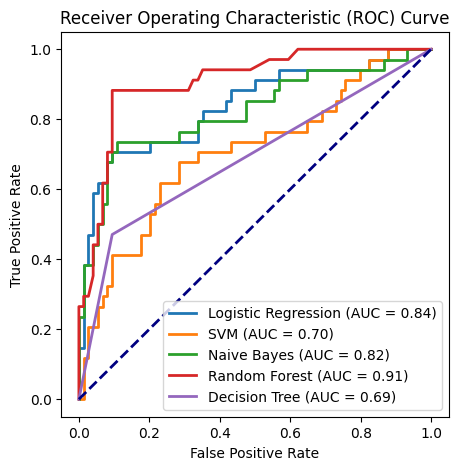

In [168]:
from sklearn.metrics import roc_curve, auc
# Initialize the classifiers
models = {
    'Logistic Regression': LogisticRegression(),
    'SVM': SVC(probability=True),  # SVC needs probability=True for ROC curve
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier()
}

# Plot ROC curve for each model
plt.figure(figsize=(5, 5))
for model_name, model in models.items():
    # Train the model
    model.fit(x_train1, y_train1)
    
    # Get the predicted probabilities for the positive class
    y_probs = model.predict_proba(x_test1)[:, 1]
    
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_test1, y_probs)
    roc_auc = auc(fpr, tpr)
    
    # Plot the ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')

# Show the plot
plt.show()

In [169]:
joblib.dump(random_forest_pa, 'pcos_rf.pkl')
print("cela passe avec succes")

cela passe avec succes


In [170]:
probabilities = random_forest_pa.predict_proba(x_test1)
certainty = probabilities[:, 1] * 100